In [124]:
import random
from copy import deepcopy
import networkx as nx
from tqdm import tqdm
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkit as nk
from sklearn.metrics import accuracy_score

from x_transformers.x_transformers import AttentionLayers
import torch.nn as nn
import torch

from utils.earlystopping import EarlyStopping

# LT+ propagation model

In [125]:
def topology_weights(G):
    tw = dict()
    for u in G:
        in_edges = G.in_edges(u)
        indegree = len(in_edges)
        for (v, _) in in_edges:
            tw[(v, u)] = 1 / indegree
    return tw

In [126]:
def attribute_weights(G):
    aw = dict()
    for u in G:
        in_edges = G.in_edges(u)
        total = 0
        for (v, _) in in_edges:
            total += G[v][u]['weight']
        # -----------------
        if total > 1:
            for (v, _) in in_edges:
                aw[(v, u)] = G[v][u]['weight'] / total
        else:
            for (v, _) in in_edges:
                aw[(v, u)] = G[v][u]['weight'] 
        # -----------------
        # for (v, _) in in_edges:
        #     aw[(v, u)] = G[v][u]['weight'] / total if total > 0 else 0
        # -----------------
    return aw

In [127]:
def run_LT(G, S, tw, aw, alpha1=0.5, alpha2=0.5):
    '''
    Input: G -- networkx directed graph
    S -- initial seed set of nodes
    '''

    assert type(G) == nx.DiGraph, 'Graph G should be an instance of networkx.DiGraph'
    assert type(S) == list, 'Seed set S should be an instance of list'

    T = deepcopy(S)  # targeted set
    lv = dict()  # threshold for nodes
    for u in G:
        lv[u] = random.random()
    W = dict(zip(G.nodes(), [0]*len(G)))  # weighted number of activated in-neighbors

    Sj = deepcopy(S)  
    while len(Sj):  # while we have newly activated nodes
        Snew = []
        for u in Sj:
            for v in G[u]:  # In G，Sj u's out edge to v。
                if v not in T:
                    # W[v] += (alpha1 * (1 / G.in_degree(v)) + alpha2 * G[u][v]['weight'])
                    W[v] += (alpha1 * tw[(u, v)] + alpha2 * aw[(u, v)])
                    if W[v] >= lv[v]:  # if greater than threshold
                        Snew.append(v)
                        T.append(v)
        Sj = deepcopy(Snew)
        
    return T

In [128]:
def cos_sim(emb1, emb2):
    return np.dot(emb1, emb2)/(np.linalg.norm(emb1) * np.linalg.norm(emb2))

# IC+ propagation model

In [129]:
def run_IC (G, S, tw, aw):
    ''' Runs independent cascade model.
    Input: G -- networkx graph object
    S -- initial set of vertices
    p -- propagation probability
    Output: T -- resulted influenced set of vertices (including S)
    '''

    T = deepcopy(S) # copy already selected nodes
    for u in T: 
        for v in G[u]: # check whether new node v is influenced by chosen node u
            p = tw[(u, v)] * aw[(u, v)]
            if (v not in T) and (random.random() < p):
                T.append(v)
    return T

In [130]:
def get_simulation_result(G, sorted_nodes, tw, aw, propagation_model, num_starts, num_runs):
    infl = []
    for num in tqdm(num_starts):
        start_nodes = sorted_nodes[:num]
        all_infl = []
        if propagation_model == 'LT':
            for _ in range(num_runs):
                all_infl.append(len(run_LT(G, S=start_nodes, tw=tw, aw=aw)))
        elif propagation_model == 'IC':
            for _ in range(num_runs):
                all_infl.append(len(run_IC(G, S=start_nodes, tw=tw, aw=aw)))
        else:
            print('Unknowm propagation model')
        mean_infl = np.mean(all_infl) / len(G)
        infl.append(mean_infl)
    return infl

# Cora dataset

In [131]:
with open('/home/lkovtun/impnodes/attributed_datasets/Cora/cora.content', 'r') as f:
    content_lines = f.readlines()

vocab_size = 1433
cora_dict = {}

for i in tqdm(range(len(content_lines))):
    ind_split0 = content_lines[i].find('\t')
    ind_split1 = content_lines[i].rfind('\t')
    emb = list(re.sub('\t', '', content_lines[i][ind_split0+1:ind_split1]))
    assert len(emb) == vocab_size
    cora_dict[content_lines[i][:ind_split0]] = {'emb': emb, 'label': re.sub('\n', '', content_lines[i][ind_split1+1:])}

with open('/home/lkovtun/impnodes/attributed_datasets/Cora/cora.cites', 'r') as f:
    cite_lines = f.readlines()

for n in cora_dict:
    cora_dict[n]['out'] = []

for i in tqdm(range(len(cite_lines))):
    ind_split0 = cite_lines[i].find('\t')
    ind_split1 = cite_lines[i].find('\n')
    paper1 = cite_lines[i][:ind_split0]
    paper2 = cite_lines[i][ind_split0+1:ind_split1]
    # paper2 --> paper1
    cora_dict[paper1]['out'].append(paper2) 

for u in cora_dict:
    cora_dict[u]['emb'] = list(map(int, cora_dict[u]['emb']))


100%|██████████| 5429/5429 [00:00<00:00, 991287.99it/s]


In [132]:
cora_dict['31336'].keys()

dict_keys(['emb', 'label', 'out'])

# Pubmed dataset

In [16]:
with open('/home/lkovtun/impnodes/attributed_datasets/Pubmed/Pubmed.content', 'r') as f:
    content_lines = f.readlines()

init_features = content_lines[1].split('\t')[1:-1]
feature_order = [feat.split('numeric:')[1].split(':0.0')[0] for feat in init_features]

vocab_size = 500
pubmed_dict = {}

for line_num in range(2, len(content_lines)):
    content = content_lines[line_num].split('\t')
    node = content[0]
    label = content[1].split('=')[1]
    features = [fl.split('=') for fl in content[2:-1]]
    feature_dict = {feat: float(value) for [feat, value] in features}
    pubmed_dict[node] = {'emb': [feature_dict[feat] if feat in feature_dict else 0 for feat in feature_order], 'label': label}

with open('/home/lkovtun/impnodes/attributed_datasets/Pubmed/Pubmed.cites', 'r') as f:
    cite_lines = f.readlines()

for n in pubmed_dict:
    pubmed_dict[n]['out'] = []

for line_num in range(2, len(cite_lines)):
    paper1 = cite_lines[line_num].split(':')[1].split('\t')[0]
    paper2 = cite_lines[line_num].split(':')[2].split('\n')[0]
    pubmed_dict[paper1]['out'].append(paper2) 

# Citeseer dataset

In [210]:
with open('/home/lkovtun/impnodes/attributed_datasets/Citeseer/citeseer.content', 'r') as f:
    content_lines = f.readlines()

vocab_size = 3703
citeseer_dict = {}

for i in tqdm(range(len(content_lines))):
    ind_split0 = content_lines[i].find('\t')
    ind_split1 = content_lines[i].rfind('\t')
    emb = list(re.sub('\t', '', content_lines[i][ind_split0+1:ind_split1]))
    assert len(emb) == vocab_size
    citeseer_dict[content_lines[i][:ind_split0]] = {'emb': emb, 'label': re.sub('\n', '', content_lines[i][ind_split1+1:])}

with open('/home/lkovtun/impnodes/attributed_datasets/Citeseer/citeseer.cites', 'r') as f:
    cite_lines = f.readlines()

for n in citeseer_dict:
    citeseer_dict[n]['out'] = []

for i in tqdm(range(len(cite_lines))):
    ind_split0 = cite_lines[i].find('\t')
    ind_split1 = cite_lines[i].find('\n')
    paper1 = cite_lines[i][:ind_split0]
    paper2 = cite_lines[i][ind_split0+1:ind_split1]
    # paper2 --> paper1
    if (paper1 in citeseer_dict) and (paper2 in citeseer_dict):
        citeseer_dict[paper1]['out'].append(paper2) 
    else:
        continue

for u in citeseer_dict:
    citeseer_dict[u]['emb'] = list(map(int, citeseer_dict[u]['emb']))

100%|██████████| 4732/4732 [00:00<00:00, 848000.28it/s]


# Washington dataset

In [447]:
with open('/home/lkovtun/impnodes/attributed_datasets/Washington/washington.content', 'r') as f:
    content_lines = f.readlines()

vocab_size = 1703
washington_dict = {}

for i in tqdm(range(len(content_lines))):
    ind_split0 = content_lines[i].find('\t')
    ind_split1 = content_lines[i].rfind('\t')
    emb = list(re.sub('\t', '', content_lines[i][ind_split0+1:ind_split1]))
    assert len(emb) == vocab_size
    washington_dict[content_lines[i][:ind_split0]] = {'emb': emb, 'label': re.sub('\n', '', content_lines[i][ind_split1+1:])}

with open('/home/lkovtun/impnodes/attributed_datasets/Washington/washington.cites', 'r') as f:
    cite_lines = f.readlines()

for n in washington_dict:
    washington_dict[n]['out'] = []

for i in tqdm(range(len(cite_lines))):
    split1 = cite_lines[i].split(' ')
    paper1 = split1[0]
    paper2 = split1[1].split('\n')[0]
    washington_dict[paper1]['out'].append(paper2) 

for u in washington_dict:
    washington_dict[u]['emb'] = list(map(int, washington_dict[u]['emb']))

100%|██████████| 446/446 [00:00<00:00, 1059863.79it/s]


# Texas dataset

In [463]:
with open('/home/lkovtun/impnodes/attributed_datasets/Texas/texas.content', 'r') as f:
    content_lines = f.readlines()

vocab_size = 1703
texas_dict = {}

for i in tqdm(range(len(content_lines))):
    ind_split0 = content_lines[i].find('\t')
    ind_split1 = content_lines[i].rfind('\t')
    emb = list(re.sub('\t', '', content_lines[i][ind_split0+1:ind_split1]))
    assert len(emb) == vocab_size
    texas_dict[content_lines[i][:ind_split0]] = {'emb': emb, 'label': re.sub('\n', '', content_lines[i][ind_split1+1:])}

with open('/home/lkovtun/impnodes/attributed_datasets/Texas/texas.cites', 'r') as f:
    cite_lines = f.readlines()

for n in texas_dict:
    texas_dict[n]['out'] = []

for i in tqdm(range(len(cite_lines))):
    split1 = cite_lines[i].split(' ')
    paper1 = split1[0]
    paper2 = split1[1].split('\n')[0]
    texas_dict[paper1]['out'].append(paper2) 

for u in texas_dict:
    texas_dict[u]['emb'] = list(map(int, texas_dict[u]['emb']))

100%|██████████| 328/328 [00:00<00:00, 999078.95it/s]


# Construct graph from data

In [464]:
data_dict = texas_dict

In [465]:
G = nx.DiGraph()
for u in data_dict:
    G.add_node(u)
    if len(data_dict[u]['out']) >= 1:
        for v in data_dict[u]['out']:
            G.add_edge(u, v)
            G[u][v]['weight'] = cos_sim(data_dict[u]['emb'], data_dict[v]['emb'])
            G[u][v]['reverse_weight'] = 1-cos_sim(data_dict[u]['emb'], data_dict[v]['emb'])


In [466]:
len(G.nodes()), len(G.edges())

(187, 328)

In [467]:
tw = topology_weights(G)
aw = attribute_weights(G)


# Baselines

### Check the direction of edges!

In [468]:
closeness = nx.closeness_centrality(G.to_undirected())
closeness_sorted = {k: v for k, v in sorted(closeness.items(), key=lambda item: item[1], reverse=True)}
closeness_nodes = list(closeness_sorted.keys())

In [469]:
betweenness = nx.betweenness_centrality(G.to_undirected())
betweenness_sorted = {k: v for k, v in sorted(betweenness.items(), key=lambda item: item[1], reverse=True)}
betweenness_nodes = list(betweenness_sorted.keys())

In [470]:
betweenness_weighted = nx.betweenness_centrality(G.to_undirected(), weight='reverse_weight')
betweenness_weighted_sorted = {k: v for k, v in sorted(betweenness_weighted.items(), key=lambda item: item[1], reverse=True)}
betweenness_weighted_nodes = list(betweenness_weighted_sorted.keys())

In [471]:
katz = nx.katz_centrality(G)
katz_sorted = {k: v for k, v in sorted(katz.items(), key=lambda item: item[1], reverse=True)}
katz_nodes = list(katz_sorted.keys())

In [472]:
pagerank = nx.pagerank(G.to_undirected())
pagerank_sorted = {k: v for k, v in sorted(pagerank.items(), key=lambda item: item[1], reverse=True)}
pagerank_nodes = list(pagerank_sorted.keys())

In [473]:
degree = nx.degree_centrality(G)
degree_sorted = {k: v for k, v in sorted(degree.items(), key=lambda item: item[1], reverse=True)}
degree_nodes = list(degree_sorted.keys())

In [474]:
indegree = nx.in_degree_centrality(G)
indegree_sorted = {k: v for k, v in sorted(indegree.items(), key=lambda item: item[1], reverse=True)}
indegree_nodes = list(indegree_sorted.keys())

In [475]:
outdegree = nx.out_degree_centrality(G)
outdegree_sorted = {k: v for k, v in sorted(outdegree.items(), key=lambda item: item[1], reverse=True)}
outdegree_nodes = list(outdegree_sorted.keys())

In [476]:
random_nodes = list(G.nodes())
random.shuffle(random_nodes)

In [477]:
num_starts=np.arange(5, 50, step=5)
num_runs = 1000

closeness_sim = get_simulation_result(G, closeness_nodes, tw, aw, 'LT', num_starts, num_runs)
betwenness_sim = get_simulation_result(G, betweenness_nodes, tw, aw, 'LT', num_starts, num_runs)
betwenness_weighted_sim = get_simulation_result(G, betweenness_weighted_nodes, tw, aw, 'LT', num_starts, num_runs)
katz_sim = get_simulation_result(G, katz_nodes, tw, aw, 'LT', num_starts, num_runs)
pagerank_sim = get_simulation_result(G, pagerank_nodes, tw, aw, 'LT', num_starts, num_runs)
degree_sim = get_simulation_result(G, degree_nodes, tw, aw, 'LT', num_starts, num_runs)
indegree_sim = get_simulation_result(G, indegree_nodes, tw, aw, 'LT', num_starts, num_runs)
outdegree_sim = get_simulation_result(G, outdegree_nodes, tw, aw, 'LT', num_starts, num_runs)
random_sim = get_simulation_result(G, random_nodes, tw, aw, 'LT', num_starts, num_runs)

100%|██████████| 9/9 [00:01<00:00,  8.03it/s]


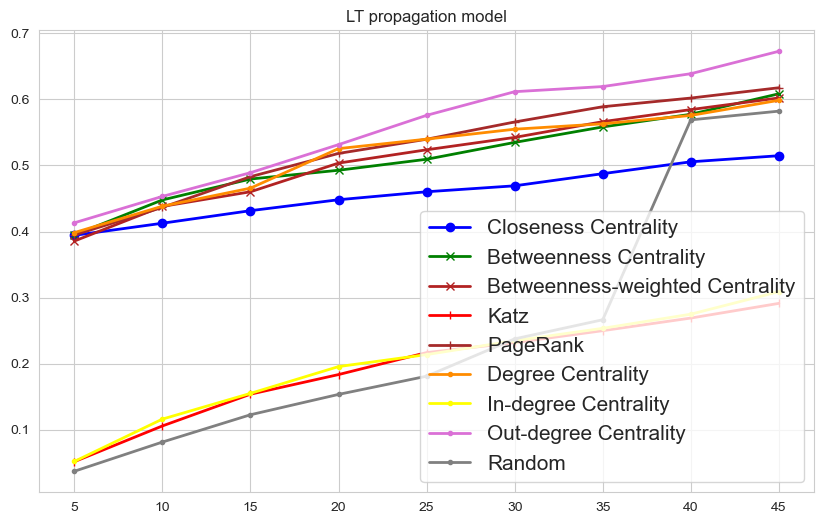

In [478]:
plt.figure(figsize=(10, 6))
plt.title('LT propagation model')
plt.plot(num_starts, closeness_sim, marker='o', linewidth=2, color='blue', label='Closeness Centrality')
plt.plot(num_starts, betwenness_sim, marker='x', linewidth=2, color='green', label='Betweenness Centrality')
plt.plot(num_starts, betwenness_weighted_sim, marker='x', linewidth=2, color='firebrick', label='Betweenness-weighted Centrality')
plt.plot(num_starts, katz_sim, marker='|', linewidth=2, color='red', label='Katz')
plt.plot(num_starts, pagerank_sim, marker='+', linewidth=2, color='brown', label='PageRank')
plt.plot(num_starts, degree_sim, marker='.', linewidth=2, color='darkorange', label='Degree Centrality')
plt.plot(num_starts, indegree_sim, marker='.', linewidth=2, color='yellow', label='In-degree Centrality')
plt.plot(num_starts, outdegree_sim, marker='.', linewidth=2, color='orchid', label='Out-degree Centrality')
plt.plot(num_starts, random_sim, marker='.', linewidth=2, color='gray', label='Random')
plt.legend(fontsize=15)
plt.grid(True)


In [479]:
closeness_sim = get_simulation_result(G, closeness_nodes, tw, aw, 'IC', num_starts, num_runs)
betwenness_sim = get_simulation_result(G, betweenness_nodes, tw, aw, 'IC', num_starts, num_runs)
betwenness_weighted_sim = get_simulation_result(G, betweenness_weighted_nodes, tw, aw, 'IC', num_starts, num_runs)
katz_sim = get_simulation_result(G, katz_nodes, tw, aw, 'IC', num_starts, num_runs)
pagerank_sim = get_simulation_result(G, pagerank_nodes, tw, aw, 'IC', num_starts, num_runs)
degree_sim = get_simulation_result(G, degree_nodes, tw, aw, 'IC', num_starts, num_runs)
indegree_sim = get_simulation_result(G, indegree_nodes, tw, aw, 'IC', num_starts, num_runs)
outdegree_sim = get_simulation_result(G, outdegree_nodes, tw, aw, 'IC', num_starts, num_runs)
random_sim = get_simulation_result(G, random_nodes, tw, aw, 'IC', num_starts, num_runs)

100%|██████████| 9/9 [00:00<00:00, 18.77it/s]


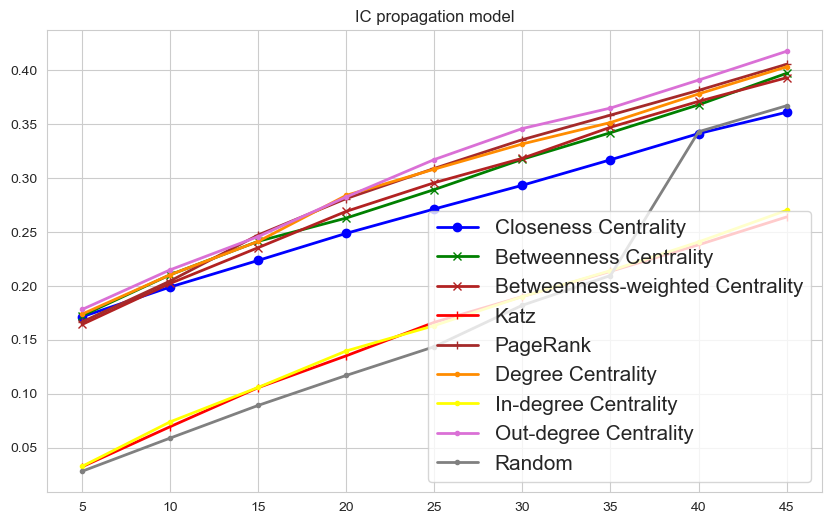

In [480]:
plt.figure(figsize=(10, 6))
plt.title('IC propagation model')
plt.plot(num_starts, closeness_sim, marker='o', linewidth=2, color='blue', label='Closeness Centrality')
plt.plot(num_starts, betwenness_sim, marker='x', linewidth=2, color='green', label='Betweenness Centrality')
plt.plot(num_starts, betwenness_weighted_sim, marker='x', linewidth=2, color='firebrick', label='Betweenness-weighted Centrality')
plt.plot(num_starts, katz_sim, marker='|', linewidth=2, color='red', label='Katz')
plt.plot(num_starts, pagerank_sim, marker='+', linewidth=2, color='brown', label='PageRank')
plt.plot(num_starts, degree_sim, marker='.', linewidth=2, color='darkorange', label='Degree Centrality')
plt.plot(num_starts, indegree_sim, marker='.', linewidth=2, color='yellow', label='In-degree Centrality')
plt.plot(num_starts, outdegree_sim, marker='.', linewidth=2, color='orchid', label='Out-degree Centrality')
plt.plot(num_starts, random_sim, marker='.', linewidth=2, color='gray', label='Random')
plt.legend(fontsize=15)
plt.grid(True)

# PINE

In [481]:
def graph_shortest_paths(G, min_length=4):
    path = dict(nx.all_pairs_shortest_path(G))
    list_path = []
    for s in tqdm(path.keys()):
        for t in path[s].keys():
            if (len(path[s][t]) >= min_length):
                list_path.append(path[s][t])
    return list_path

In [482]:
list_path = graph_shortest_paths(G)

100%|██████████| 187/187 [00:00<00:00, 769710.35it/s]


In [483]:
len(list_path)

295

In [484]:
vocab_dict = {node: (i+1) for i, node in enumerate(G.nodes())}

In [485]:
train_path = [path[:-2] for path in list_path]
valid_path = [path[:-1] for path in list_path]
test_path = [path for path in list_path]

In [486]:
def get_unique_path(path_sample):
    unique_path = []
    contexts = []
    for path in tqdm(path_sample):
        if path[:-1] not in contexts:
            unique_path.append(path)
            contexts.append(path[:-1])  
    return unique_path

In [487]:
unique_train_path = get_unique_path(train_path)
unique_valid_path = get_unique_path(valid_path)
unique_test_path = get_unique_path(test_path)

100%|██████████| 295/295 [00:00<00:00, 627126.04it/s]


In [488]:
len(unique_train_path), len(train_path)

(115, 295)

In [489]:
len(unique_valid_path), len(valid_path)

(132, 295)

In [490]:
len(unique_test_path), len(test_path)

(176, 295)

In [491]:
class AttentionPath(nn.Module):
    def __init__(self, emb_dim, num_classes, hidden_size=64):
        super(AttentionPath, self).__init__()

        self.emb_dim = emb_dim
        self.num_classes = num_classes
        self.hidden_size = hidden_size

        self.input_linear = nn.Linear(self.emb_dim, self.hidden_size)
        self.norm = nn.LayerNorm(self.hidden_size)
        self.attention = AttentionLayers(dim=self.hidden_size, depth=1, heads=1, causal=True)
        # self.lstm =  nn.LSTM(
        #         self.hidden_size,
        #         self.hidden_size,
        #         num_layers=2,
        #         batch_first=True,
        #         bidirectional=False)
        self.linear_out = nn.Linear(self.hidden_size, self.num_classes)

    def forward(self, x, mask):
        z = self.input_linear(x)
        z = self.norm(z)
        z, hiddens = self.attention(z, mask=mask, return_hiddens=True)
        # z, _ = self.lstm(z)
        out = self.linear_out(z)
        last_out = [out[b, (torch.sum(mask[b, :]).item())-1, :].unsqueeze(0) for b in range(mask.shape[0])]
        return torch.cat(last_out, dim=0), hiddens

    

In [492]:
# def get_node_class(measure_dict, num_bins):
#     measure_values = list(measure_dict.values())
#     eps = 1e-5
#     bin_borders = [[np.percentile(measure_values, int(i * (100 / num_bins))), np.percentile(measure_values, int((i+1) * (100 / num_bins)))]
#                 for i in range(num_bins)]

#     bin_borders[0][0] = bin_borders[0][0] - eps
#     bin_borders[-1][-1] = bin_borders[-1][-1] + eps

#     node_class = {}
#     for node in measure_dict:
#         nd = measure_dict[node]
#         for n, (lb, rb) in enumerate(bin_borders):
#             if (lb <= nd) and (nd < rb):
#                 node_class[node] = n
#     return node_class


In [493]:
# num_bins = 5
# node_class = get_node_class(katz_sorted, num_bins)

In [494]:
# ALTERNATIVE NODE CLASS

unique_labels = np.unique([data_dict[node]['label'] for node in data_dict])
topic_dict = {topic: i for i, topic in enumerate(unique_labels)}

node_class = {}
for node in G.nodes():
    node_class[node] = topic_dict[data_dict[node]['label']]

In [495]:
np.unique(list(node_class.values()), return_counts=True) 

(array([0, 1, 2, 3, 4]), array([ 34,  31,  18,   1, 103]))

In [496]:
class PathDataset(torch.utils.data.Dataset):
    def __init__(self, 
                 list_shortest_paths, 
                 emb_dict, 
                 label_dict,
                 vocab_dict, 
                 phase):
        self.list_shortest_paths = list_shortest_paths
        self.emb_dict = emb_dict
        self.label_dict = label_dict
        self.vocab_dict = vocab_dict
        self.phase = phase
    
    def __len__(self):
        return len(self.list_shortest_paths)
    
    def __getitem__(self, idx):
        path = self.list_shortest_paths[idx]
        emb_path = [self.emb_dict[node]['emb'] for node in path]
        x = torch.tensor(emb_path, dtype=torch.float32)
        path_label = [self.label_dict[node] for node in path]
        y = torch.tensor(path_label, dtype=torch.int64)
        id_path =[self.vocab_dict[node] for node in self.list_shortest_paths[idx]]
        p = torch.tensor(id_path, dtype=torch.int64)
        return x[:-1, :], y[-1], p[:-1]
        # if self.phase == 'train':
        #     return x[:-1, :], y[1:], p
        # elif (self.phase == 'valid') or (self.phase == 'test'):
        #     return x[:-1, :], y[-1], p
        # else:
        #     print('Unknown phase')

    @staticmethod
    def collate_fn(batch):
        batch_x = [x for (x, _, _) in batch]
        padded_batch_x = torch.nn.utils.rnn.pad_sequence(batch_x, batch_first=True)
        # batch_y = [y.unsqueeze(0) if len(y.shape) == 0 else y for (_, y, _) in batch]
        # padded_batch_y = torch.nn.utils.rnn.pad_sequence(batch_y, batch_first=True)
        batch_y = torch.tensor([y for (_, y, _) in batch]).reshape(-1, 1)
        lengths = [x.shape[0] for (x, _, _) in batch]
        lengths = torch.tensor(lengths, dtype=torch.int64)
        batch_mask = (torch.arange(padded_batch_x.shape[1]).repeat(len(batch), 1) < lengths.reshape(-1, 1)).type(torch.bool)
        batch_p = [p for (_, _, p) in batch]
        padded_batch_p = torch.nn.utils.rnn.pad_sequence(batch_p, batch_first=True)
        return padded_batch_x, batch_y, batch_mask, padded_batch_p

In [497]:
train_dataset = PathDataset(unique_train_path, data_dict, node_class, vocab_dict, 'train') 
train_dataloader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                               collate_fn=train_dataset.collate_fn,
                                               shuffle=True,
                                               batch_size=32)

valid_dataset = PathDataset(unique_valid_path, data_dict, node_class, vocab_dict, 'valid') 
valid_dataloader = torch.utils.data.DataLoader(dataset=valid_dataset, 
                                               collate_fn=valid_dataset.collate_fn,
                                               shuffle=False,
                                               batch_size=32)

test_dataset = PathDataset(unique_test_path, data_dict, node_class, vocab_dict, 'test') 
test_dataloader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                              collate_fn=test_dataset.collate_fn,
                                              shuffle=False,
                                              batch_size=32)

In [498]:
device = 'cuda:0'
model = AttentionPath(emb_dim=vocab_size, num_classes=len(topic_dict)).to(device) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) 
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.9)
ce_loss = nn.CrossEntropyLoss()
early_stopping = EarlyStopping(patience=3, verbose=True, path='checkpoint.pt')

In [499]:
num_epochs = 20

In [500]:
epoch_train_loss = []
epoch_train_metric = []
epoch_valid_loss = []
epoch_valid_metric = []
for epoch in range(num_epochs):
    model.train()
    train_losses = []
    train_preds = []
    train_gt = []
    for i, (x, y, mask, p) in tqdm(enumerate(train_dataloader)):
        x, y, mask = x.to(device), y.to(device), mask.to(device)
        optimizer.zero_grad()
        preds, _ = model(x, mask)
        loss_val = ce_loss(preds, y.squeeze(1))
        train_preds.extend(torch.argmax(preds, dim=1).detach().cpu().numpy().tolist())
        train_gt.extend(y.squeeze(1).detach().cpu().numpy().tolist())
        train_losses.append(loss_val.item())
        loss_val.backward()
        optimizer.step()
    mean_train_loss = np.mean(train_losses)
    epoch_train_loss.append(mean_train_loss)
    train_metric = accuracy_score(train_gt, train_preds)
    epoch_train_metric.append(train_metric)
    print(f'Epoch {epoch}: Train Loss',mean_train_loss)
    print(f'Epoch {epoch}: Train MCA', train_metric)
    scheduler.step()

    model.eval()
    valid_losses = []
    valid_preds = []
    valid_gt = []
    for i, (x, y, mask, p) in tqdm(enumerate(valid_dataloader)):
        x, y, mask = x.to(device), y.to(device), mask.to(device)
        preds, _ = model(x, mask)
        loss0 = ce_loss(preds, y.squeeze(1))
        valid_losses.append(loss0.item())
        valid_preds.extend(torch.argmax(preds, dim=1).detach().cpu().numpy().tolist())
        valid_gt.extend(y.squeeze(1).detach().cpu().numpy().tolist())
    mean_valid_loss = np.mean(valid_losses)
    epoch_valid_loss.append(mean_valid_loss)
    valid_metric = accuracy_score(valid_gt, valid_preds)
    epoch_valid_metric.append(valid_metric)
    print(f'Epoch {epoch}: Valid Loss', mean_valid_loss)
    print(f'Epoch {epoch}: Valid MCA', valid_metric)

    early_stopping(mean_valid_loss, model)
    if early_stopping.early_stop:
        print('Early stopping')
        break



4it [00:00, 38.02it/s]


Epoch 0: Train Loss 1.604478657245636
Epoch 0: Train MCA 0.3391304347826087


5it [00:00, 52.67it/s]


Epoch 0: Valid Loss 1.4975303888320923
Epoch 0: Valid MCA 0.3409090909090909
Validation loss decreased (inf --> 1.497530).  Saving model ...


4it [00:00, 49.16it/s]


...

Epoch 3: Valid Loss 1.5780238389968873
Epoch 3: Valid MCA 0.38636363636363635
EarlyStopping counter: 2 out of 3


4it [00:00, 47.73it/s]


Epoch 4: Train Loss 0.5876760631799698
Epoch 4: Train MCA 0.8608695652173913


5it [00:00, 59.10it/s]

Epoch 4: Valid Loss 1.630319094657898
Epoch 4: Valid MCA 0.38636363636363635
EarlyStopping counter: 3 out of 3
Early stopping


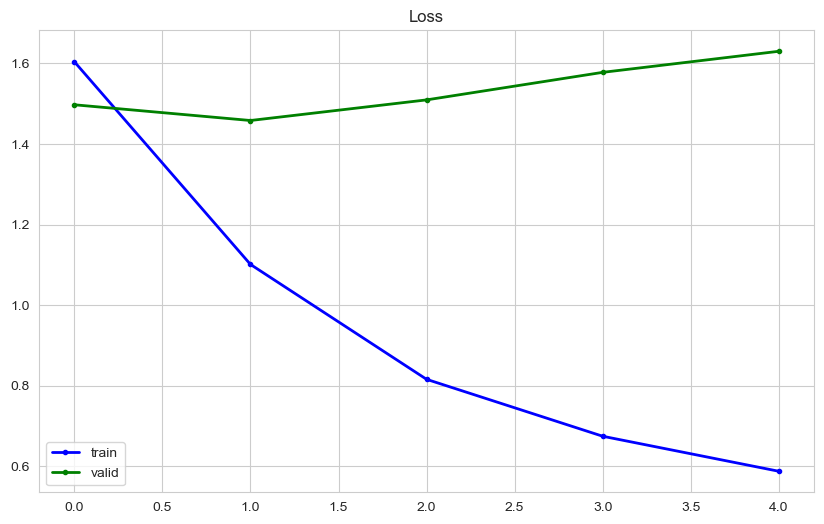

In [501]:
plt.figure(figsize=(10, 6))
plt.title('Loss')
plt.plot(np.arange(len(epoch_train_loss)), epoch_train_loss, linewidth=2, marker='.', color='blue', label='train')
plt.plot(np.arange(len(epoch_valid_loss)), epoch_valid_loss, linewidth=2, marker='.', color='green', label='valid')
plt.legend()
plt.grid(True)

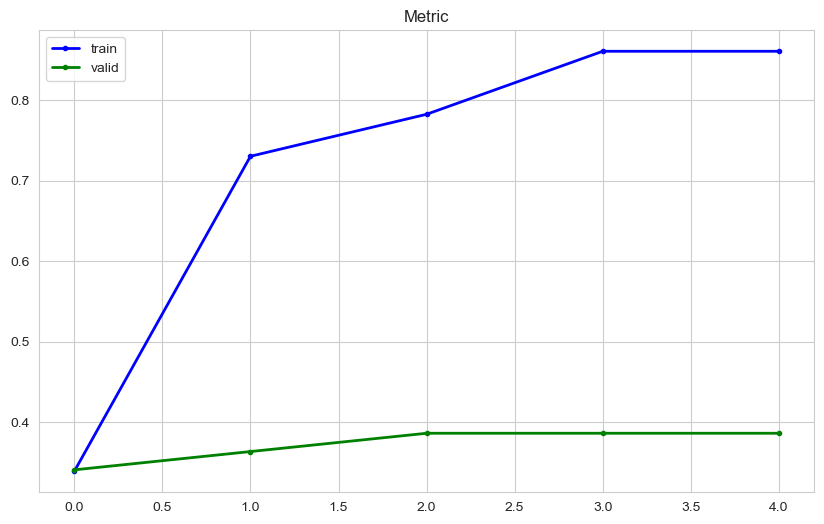

In [502]:
plt.figure(figsize=(10, 6))
plt.title('Metric')
plt.plot(np.arange(len(epoch_train_metric)), epoch_train_metric, linewidth=2, marker='.', color='blue', label='train')
plt.plot(np.arange(len(epoch_valid_metric)), epoch_valid_metric, linewidth=2, marker='.', color='green', label='valid')
plt.legend()
plt.grid(True)

In [503]:
id2node = {}
for node in vocab_dict:
    id2node[vocab_dict[node]] = node

In [504]:
model.eval()
test_preds = []
test_gt = []

path_imp = {id: [] for id in id2node}
node_freq = {id: 0 for id in id2node}
node_outneigh = {id: [] for id in id2node}

for i, (x, y, mask, p) in tqdm(enumerate(test_dataloader)):
    x, y, mask = x.to(device), y.to(device), mask.to(device)
    preds, hiddens = model(x, mask)
    test_preds.extend(torch.argmax(preds, dim=1).detach().cpu().numpy().tolist())
    test_gt.extend(y.squeeze(1).detach().cpu().numpy().tolist())

    att = hiddens.attn_intermediates[0].post_softmax_attn.squeeze(1).detach().cpu().numpy()
    id_p = p.detach().cpu().numpy().tolist()
    for b in range(att.shape[0]):
        seq_length = torch.sum(mask[b, :]).item()
        imp_distr = att[b, -1, :seq_length]
        # 1) sum attention
        for j, id in enumerate(id_p[b][:seq_length]):
            path_imp[id] += imp_distr[j] 
            node_freq[id] += 1
        # max rank
        # j_max = np.argmax(imp_distr)
        # path_imp[id_p[b][j_max]] += 1
        # post infl
        # for j, id in enumerate(id_p[b][:seq_length-1]):
        #     path_imp[id].append(1)
        #     node_outneigh[id].append(id_p[b][j+1])

test_metric = accuracy_score(test_gt, test_preds)
print(f'Test MCA', test_metric)

6it [00:00, 43.52it/s]

Test MCA 0.017045454545454544


In [505]:
# path_imp = {id: np.sum([np.mean(np.array(path_imp[id])[np.array(node_outneigh[id]) == uniq]) for uniq in np.unique(node_outneigh[id])]) for id in path_imp}


In [506]:
# path_imp = {id: path_imp[id] / node_freq[id] if node_freq[id] != 0 else 0 for id in path_imp}
pine_dict = {id2node[id]: path_imp[id] for id in path_imp}
# pine_dict = {node: pine_dict[node] * degree_sorted[node] for node in pine_dict}
pine_dict = {node: pine_dict[node] for node in pine_dict}
pine_dict = dict(sorted(pine_dict.items(), key=lambda x: x[1], reverse=True))

/tmp/ipykernel_1490735/1494823692.py:5: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  pine_dict = dict(sorted(pine_dict.items(), key=lambda x: x[1], reverse=True))


In [507]:
pine_nodes = list(pine_dict.keys())
pine_sim = get_simulation_result(G, pine_nodes, tw, aw, 'LT', num_starts, num_runs)

100%|██████████| 9/9 [00:01<00:00,  4.55it/s]


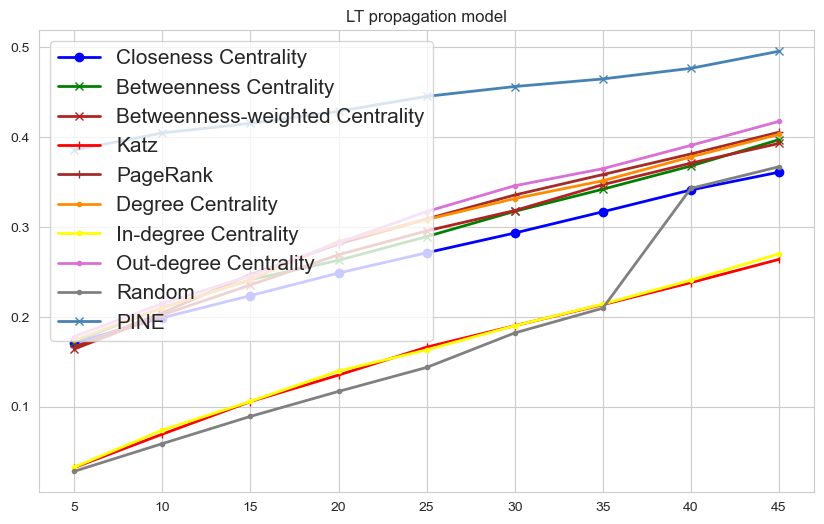

In [508]:
plt.figure(figsize=(10, 6))
plt.title('LT propagation model')
plt.plot(num_starts, closeness_sim, marker='o', linewidth=2, color='blue', label='Closeness Centrality')
plt.plot(num_starts, betwenness_sim, marker='x', linewidth=2, color='green', label='Betweenness Centrality')
plt.plot(num_starts, betwenness_weighted_sim, marker='x', linewidth=2, color='firebrick', label='Betweenness-weighted Centrality')
plt.plot(num_starts, katz_sim, marker='|', linewidth=2, color='red', label='Katz')
plt.plot(num_starts, pagerank_sim, marker='+', linewidth=2, color='brown', label='PageRank')
plt.plot(num_starts, degree_sim, marker='.', linewidth=2, color='darkorange', label='Degree Centrality')
plt.plot(num_starts, indegree_sim, marker='.', linewidth=2, color='yellow', label='In-degree Centrality')
plt.plot(num_starts, outdegree_sim, marker='.', linewidth=2, color='orchid', label='Out-degree Centrality')
plt.plot(num_starts, random_sim, marker='.', linewidth=2, color='gray', label='Random')
plt.plot(num_starts, pine_sim, marker='x', linewidth=2, color='steelblue', label='PINE')
plt.legend(fontsize=15)
plt.grid(True)


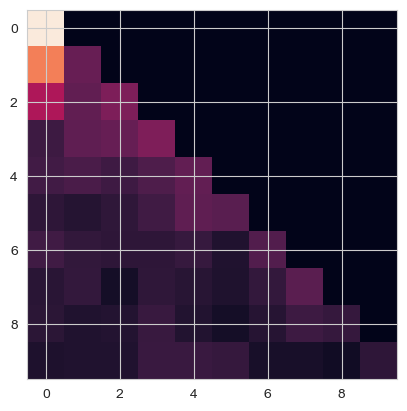

In [499]:
plt.imshow(att[-1])